<a href="https://colab.research.google.com/github/DiaElix/LearnDeepLearning/blob/main/Weight_Init_E2_DiaElizabeth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Lab Exp  2 : Weight Initialization and optimization

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.initializers import Zeros, RandomNormal, GlorotNormal, HeNormal
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.regularizers import l1, l2

load and preprocess mnist dataset

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


Weight initialization

In [ ]:
def build_model(initializer):

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


initializers = {
    "Zero": Zeros(),
    "RandomNormal": RandomNormal(mean=0.0, stddev=1.0),
    "Xavier(Glorot)": GlorotNormal(),
    "He": HeNormal()
}

init_results = {}

for name, init in initializers.items():

    model = build_model(init)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    init_results[name] = acc

print(init_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Zero': 0.11349999904632568, 'RandomNormal': 0.934499979019165, 'Xavier(Glorot)': 0.9714999794960022, 'He': 0.972599983215332}


Visualization of Initialization performance

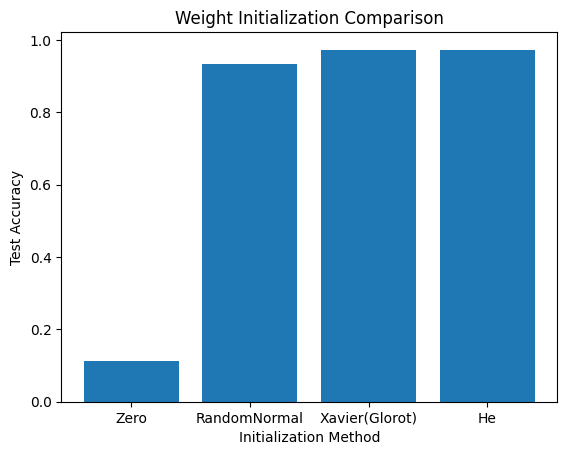

In [ ]:
plt.figure()

plt.bar(init_results.keys(), init_results.values())

plt.title("Weight Initialization Comparison")
plt.ylabel("Test Accuracy")
plt.xlabel("Initialization Method")

plt.show()

Optimization Techniques

In [ ]:
def build_optimizer_model():

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu', kernel_initializer=HeNormal()),
        Dense(10, activation='softmax')
    ])

    return model


optimizers = {
    "Batch GD": SGD(learning_rate=0.01),
    "Mini-batch SGD": SGD(learning_rate=0.01),
    "AdaGrad": Adagrad(learning_rate=0.01),
    "RMSProp": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

batch_sizes = {
    "Batch GD": len(x_train),
    "Mini-batch SGD": 128,
    "AdaGrad": 128,
    "RMSProp": 128,
    "Adam": 128
}

opt_results = {}

for name, opt in optimizers.items():

    model = build_optimizer_model()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=batch_sizes[name],
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    opt_results[name] = acc

print(opt_results)

{'Batch GD': 0.11100000143051147, 'Mini-batch SGD': 0.9079999923706055, 'AdaGrad': 0.9316999912261963, 'RMSProp': 0.9740999937057495, 'Adam': 0.9758999943733215}


Visualize optimizer performance

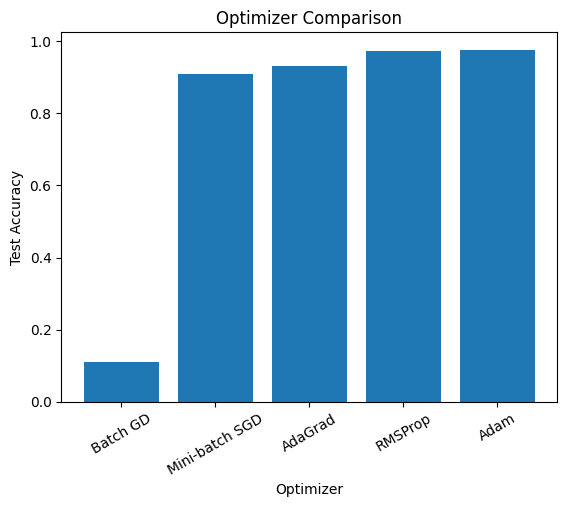

In [ ]:
plt.figure()

plt.bar(opt_results.keys(), opt_results.values())

plt.title("Optimizer Comparison")
plt.ylabel("Test Accuracy")
plt.xlabel("Optimizer")

plt.xticks(rotation=30)

plt.show()

Regularization Techniques

In [ ]:
def build_reg_model(reg_type=None):

    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))

    if reg_type == "l2":
        model.add(Dense(128, activation='relu',
                        kernel_initializer=HeNormal(),
                        kernel_regularizer=l2(0.001)))

    elif reg_type == "l1":
        model.add(Dense(128, activation='relu',
                        kernel_initializer=HeNormal(),
                        kernel_regularizer=l1(0.001)))

    elif reg_type == "dropout":
        model.add(Dense(128, activation='relu',
                        kernel_initializer=HeNormal()))
        model.add(Dropout(0.5))

    elif reg_type == "l2_dropout":
        model.add(Dense(128, activation='relu',
                        kernel_initializer=HeNormal(),
                        kernel_regularizer=l2(0.001)))
        model.add(Dropout(0.5))

    else:
        model.add(Dense(128, activation='relu',
                        kernel_initializer=HeNormal()))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


reg_types = ["none","l2","l1","dropout","l2_dropout"]

reg_results = {}

for r in reg_types:

    if r == "none":
        model = build_reg_model()
    else:
        model = build_reg_model(r)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    reg_results[r] = acc

print(reg_results)

{'none': 0.972599983215332, 'l2': 0.96670001745224, 'l1': 0.9307000041007996, 'dropout': 0.9677000045776367, 'l2_dropout': 0.9603999853134155}


Visualize Regularization Performance

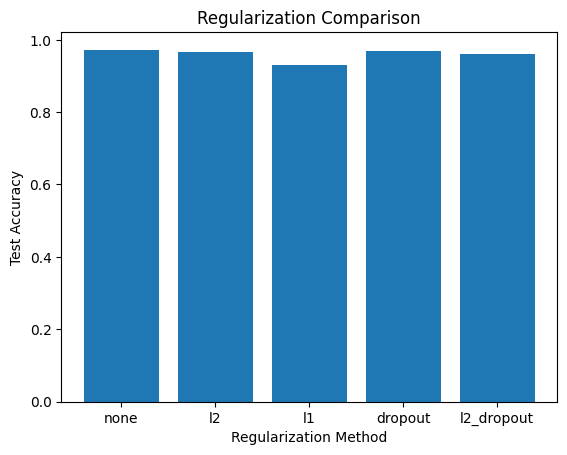

In [ ]:
plt.figure()

plt.bar(reg_results.keys(), reg_results.values())

plt.title("Regularization Comparison")
plt.ylabel("Test Accuracy")
plt.xlabel("Regularization Method")

plt.show()

Final Comparison

In [ ]:
print("\nWeight Initialization Results")
print(init_results)

print("\nOptimizer Results")
print(opt_results)

print("\nRegularization Results")
print(reg_results)


Weight Initialization Results
{'Zero': 0.11349999904632568, 'RandomNormal': 0.934499979019165, 'Xavier(Glorot)': 0.9714999794960022, 'He': 0.972599983215332}

Optimizer Results
{'Batch GD': 0.11100000143051147, 'Mini-batch SGD': 0.9079999923706055, 'AdaGrad': 0.9316999912261963, 'RMSProp': 0.9740999937057495, 'Adam': 0.9758999943733215}

Regularization Results
{'none': 0.972599983215332, 'l2': 0.96670001745224, 'l1': 0.9307000041007996, 'dropout': 0.9677000045776367, 'l2_dropout': 0.9603999853134155}
